In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas import to_datetime

CN = pd.read_csv('dataset/CN.csv', sep = ',')

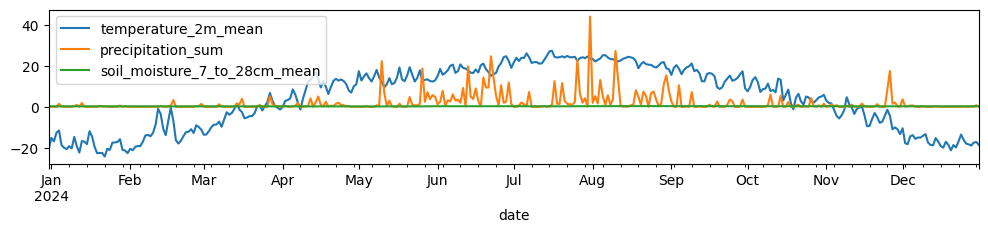

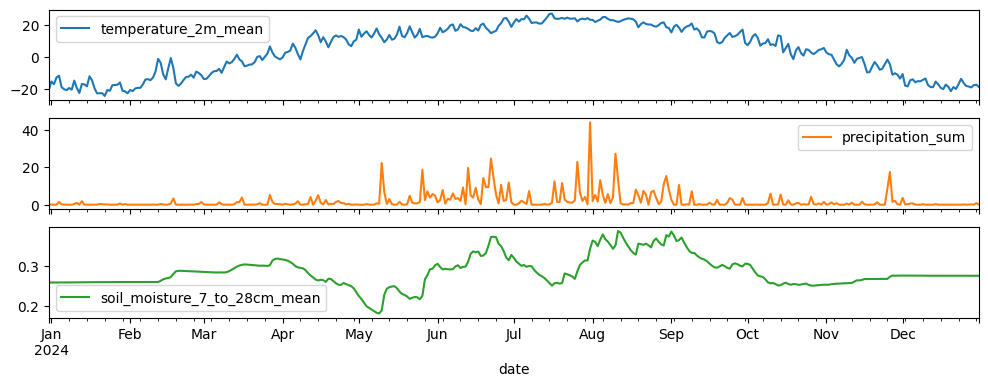

In [33]:
cities = CN["city"].unique()
for city in cities:
    CITY = CN[ (CN["city"] == city) &
             (CN["date"] > "2023-12-31") ]
    CITY.index = pd.DatetimeIndex(CITY["date"])
    CITY.plot(figsize=(12, 2))
    CITY.plot(figsize=(12, 4), subplots=True)
    break

<Axes: xlabel='date'>

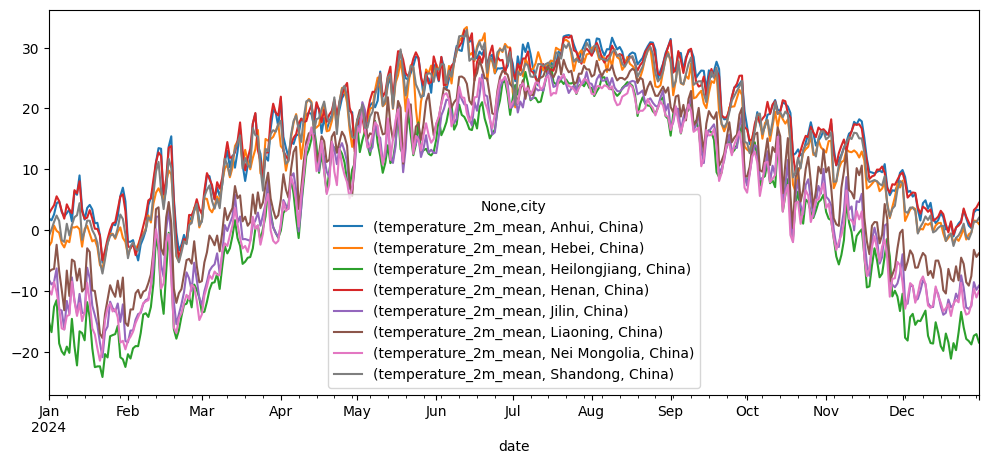

In [55]:
pivot_df = pd.pivot(CN, index = ['date'], columns = ['city'], values = ['temperature_2m_mean'])
pivot_df.index = pd.to_datetime(pivot_df.index)
pivot_df = pivot_df[ pivot_df.index > '2023-12-31' ]
pivot_df.plot(figsize=(12, 5))


In [1]:
a= {
    "city" : "Kansas, US",
    "rank" : "",
    "file" : "US(05)Kansas",
    "latitude": [39.911204, 37.152193, 37.142544, 38.110899],
    "longitude": [-95.610629, -100.783354, -94.803045, -94.827256]
}

b = ['soil_moisture_0_to_100cm_mean', 'soil_moisture_0_to_7cm_mean', 'soil_moisture_7_to_28cm_mean','soil_moisture_28_to_100cm_mean']

from src import om_api

df = om_api.daily_history(a['latitude'], a['longitude'],'2025-01-01','2025-08-30',b)



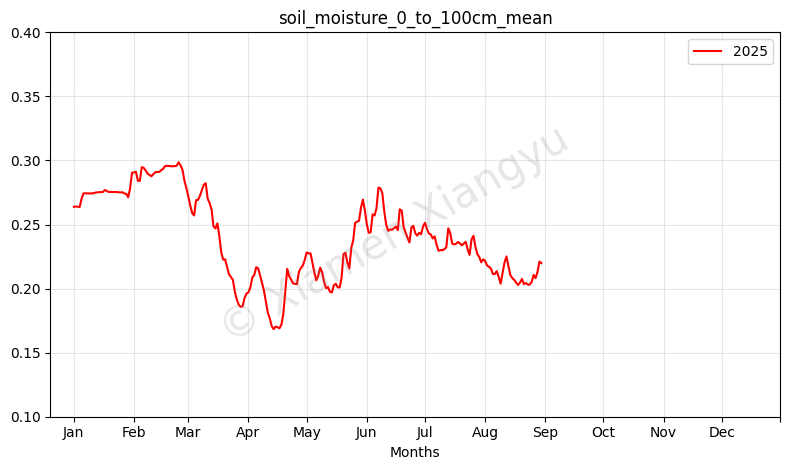

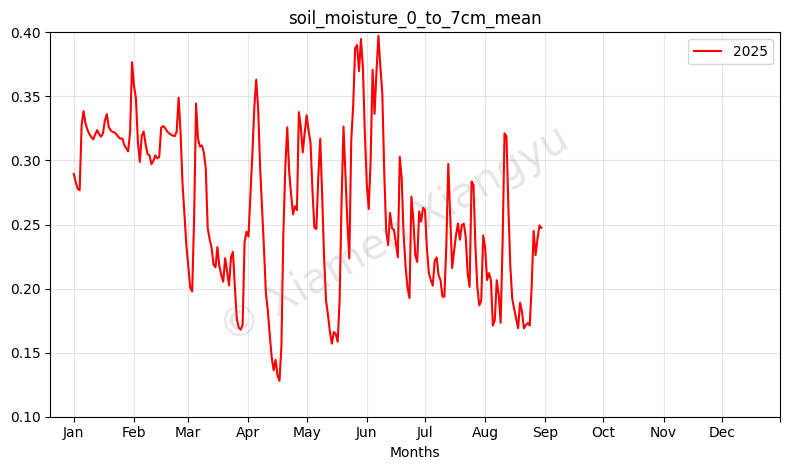

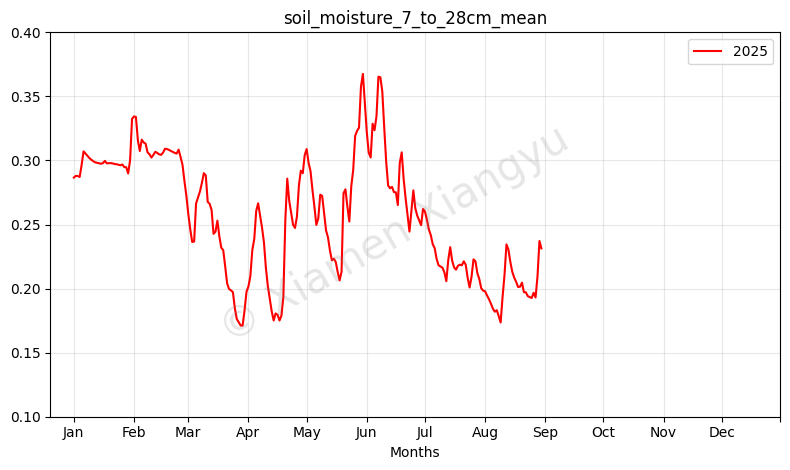

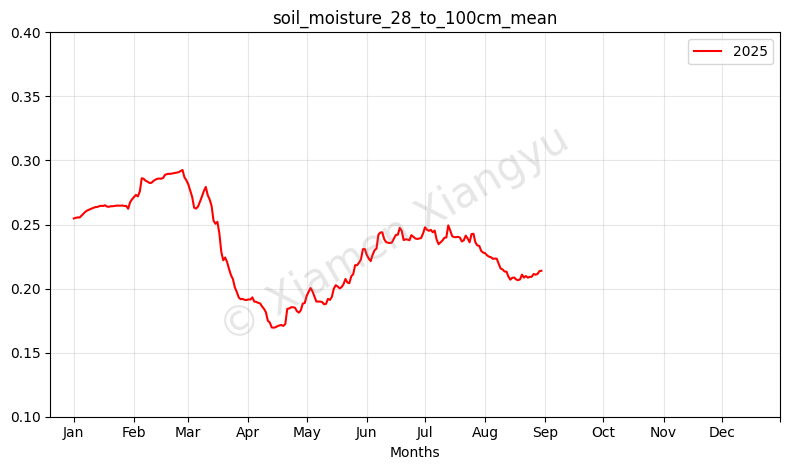

In [2]:
df2 = df.groupby(['date'])[b].mean().reset_index()
from src import charts
for c in b:
    charts.day_annul_plot(df2, c,title=c,ylim=(0.10,0.40))

